# Fitting and estimation

mixle fits models by EM by default, and also offers gradient-based maximum-likelihood / MAP fitting and pluggable EM strategies. This is the API reference for the fitting entry points; for the why (EM vs gradient convergence, MAP bias-variance, when annealing helps) see the data-science notebook em_and_map_strategies.


In [1]:
import io
import numpy as np
from mixle.stats import (GaussianDistribution, MixtureDistribution, GaussianEstimator,
                        MixtureEstimator, seq_encode, seq_log_density_sum)
from mixle.inference.estimation import optimize, best_of
from mixle.inference.gradient_fit import fit_mle, fit_map
from mixle.inference.em import (StandardEM, PosteriorTransformEM, HardEM, AnnealedEM,
                           GeneralizedEM, ConditionalMaximizationEM)
from mixle.inference.objectives import (fit_objective, variational_projection,
                                   optimize_torch_objective, fit_parameter_objective,
                                   ExpectedLogDensity, ObjectiveParameter)
from mixle.inference.priors import normal_gamma

truth = MixtureDistribution([GaussianDistribution(-2.0, 1.0), GaussianDistribution(2.0, 1.0)], [0.5, 0.5])
data = truth.sampler(seed=1).sample(400)
est = MixtureEstimator([GaussianEstimator(), GaussianEstimator()])

## EM: `optimize` and `best_of`

`optimize` runs EM until the objective settles (`delta`) or `max_its` is reached and returns the fitted distribution; the short 40-iteration budgets used here stop at the cap first, and `optimize` says so in a warning (pass `delta=None` when a fixed iteration budget is the intent). `best_of` runs several random restarts against a validation set and returns `(validation_log_likelihood, best_model)` - the restart guards against EM's local optima. A fixed number of EM steps is `optimize(..., max_its=n, delta=None)`.


In [2]:
model = optimize(data, est, max_its=40, rng=np.random.RandomState(1), out=io.StringIO())
print('optimize -> means', sorted(round(c.mu, 2) for c in model.components))

vll, best = best_of(data, data, est, trials=5, max_its=40, init_p=0.1, delta=1e-9,
                    rng=np.random.RandomState(1), out=io.StringIO())
print('best_of  -> validation ll %.2f, means %s' % (vll, sorted(round(c.mu, 2) for c in best.components)))

stepped = optimize(data, est, max_its=25, delta=None, rng=np.random.RandomState(1), out=io.StringIO())
print('25 steps -> means', sorted(round(c.mu, 2) for c in stepped.components))

optimize -> means [-2.11, 1.96]
best_of  -> validation ll -819.37, means [-2.12, 1.96]
25 steps -> means [-2.04, 2.03]


/var/folders/4k/23vz9g1x43nfgwlsdx7036hc0000gn/T/ipykernel_73371/935370110.py:1: UserWarning: optimize() stopped at the max_its cap (40) before the objective settled (last objective gain 0.000346, delta=1e-09): the returned model is an unconverged fit, and its fit_provenance() reports converged=False. Raise max_its to fit to convergence, or pass delta=None to request a fixed iteration count without this note.
  model = optimize(data, est, max_its=40, rng=np.random.RandomState(1), out=io.StringIO())
/Users/grantboquet/mixle/.ci-repro-colima/candidate-081/venv/lib/python3.12/site-packages/mixle/inference/estimation.py:2170: UserWarning: optimize() stopped at the max_its cap (40) before the objective settled (last objective gain 0.000346, delta=1e-09): the returned model is an unconverged fit, and its fit_provenance() reports converged=False. Raise max_its to fit to convergence, or pass delta=None to request a fixed iteration count without this note.
  mm = optimize(
/Users/grantboquet/mi

## Gradient fitting: `fit_mle` and `fit_map`

These take an encoded dataset and a starting model and optimize with torch autograd. `fit_mle` is maximum likelihood; `fit_map` adds a prior (`prior_strength`, or an explicit `priors=`). Both return `(fitted_model, objective_value)`.


In [3]:
enc = seq_encode(data, model=truth)
fitted, ll = fit_mle(enc, truth, max_its=200, lr=0.05, optimizer='lbfgs')   # 'adam' also available
print('fit_mle  -> ll %.2f' % ll)

fitted_map, lp = fit_map(enc, truth, prior_strength=2.0, max_its=200, optimizer='lbfgs')
ng = normal_gamma(mu0=0.0, kappa=1.0, alpha=2.0, beta=1.0)                   # explicit conjugate prior
shared_ng = {'family': 'aligned', 'prior': ng,                      # 0.8.0: one prior for many
              'alignment_receipt': {'mode': 'broadcast',             # components is now explicit
                                    'rationale': 'one conjugate prior shared by every component'}}
fitted_ng, _ = fit_map(enc, truth, priors=shared_ng, prior_strength=5.0, max_its=200, optimizer='lbfgs')
print('fit_map  -> objective %.2f (prior_strength=0 reduces to fit_mle)' % lp)

fit_mle  -> ll -819.37


fit_map  -> objective -820.84 (prior_strength=0 reduces to fit_mle)


## Swapping the E-step: `optimize(strategy=...)`

`strategy=` replaces the standard E-step with an alternative from `mixle.inference.em`, keeping the same monotone outer loop. The plug-in strategies need no arguments beyond their hyperparameters:

| strategy | what it does |
|---|---|
| `StandardEM()` | exact soft responsibilities (the default) |
| `PosteriorTransformEM(temperature=T, hard=False)` | temper responsibilities - `T>1` flattens, `T<1` sharpens |
| `HardEM()` | winner-take-all (classification EM) |
| `AnnealedEM([T1, T2, ...])` | follow a cooling schedule, ending exact |

The cell below runs each from the same start and reports the data log-likelihood it reaches. `StandardEM`/`HardEM` recover the two well-separated components; the tempering strategies (`PosteriorTransformEM(T>1)`, an aggressive `AnnealedEM` schedule) deliberately flatten the responsibilities and settle for a blurrier, lower-likelihood fit - that softening is the point of having them.


/var/folders/4k/23vz9g1x43nfgwlsdx7036hc0000gn/T/ipykernel_73371/3180023062.py:12: UserWarning: optimize() stopped at the max_its cap (40) before the objective settled (last objective gain 0.000346, delta=1e-09): the returned model is an unconverged fit, and its fit_provenance() reports converged=False. Raise max_its to fit to convergence, or pass delta=None to request a fixed iteration count without this note.
  m = optimize(data, est, max_its=40, rng=np.random.RandomState(1), strategy=strat, out=io.StringIO())
/var/folders/4k/23vz9g1x43nfgwlsdx7036hc0000gn/T/ipykernel_73371/3180023062.py:12: UserWarning: optimize() stopped at the max_its cap (40) before the objective settled (last objective gain 4.74e-05, delta=1e-09): the returned model is an unconverged fit, and its fit_provenance() reports converged=False. Raise max_its to fit to convergence, or pass delta=None to request a fixed iteration count without this note.
  m = optimize(data, est, max_its=40, rng=np.random.RandomState(1),

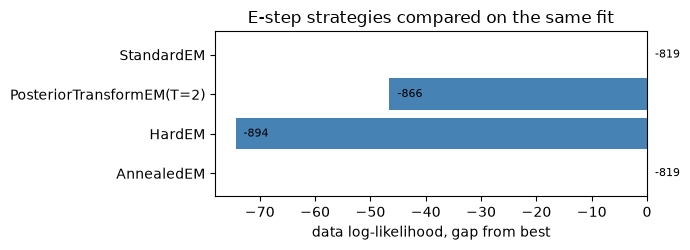

In [4]:
import matplotlib.pyplot as plt
%matplotlib inline

runs = {
    'StandardEM':                 StandardEM(),
    'PosteriorTransformEM(T=2)':  PosteriorTransformEM(temperature=2.0),
    'HardEM':                     HardEM(),
    'AnnealedEM':                 AnnealedEM([3.0, 1.5, 1.0, 1.0]),
}
lls = {}
for name, strat in runs.items():
    m = optimize(data, est, max_its=40, rng=np.random.RandomState(1), strategy=strat, out=io.StringIO())
    lls[name] = sum(m.log_density(x) for x in data)

best = max(lls.values())
fig, ax = plt.subplots(figsize=(7, 2.6))
names = list(lls)
ax.barh(names, [lls[n] - best for n in names], color='steelblue')
ax.set_xlabel('data log-likelihood, gap from best'); ax.invert_yaxis()
ax.set_title('E-step strategies compared on the same fit')
for i, n in enumerate(names):
    ax.text(lls[n] - best, i, '  %.0f' % lls[n], va='center', fontsize=8)
plt.tight_layout(); plt.show()

### Custom E-steps

Any object with a `.step(enc, estimator, model, engine) -> EMStepResult` works as a strategy. The advanced strategies take a user callable so you can build a non-standard step - and the standard step is itself reusable as a building block:


In [5]:
# reuse the exact E/M step inside a generalized-EM wrapper
def one_standard_step(enc, estimator, model, engine=None):
    return StandardEM().step(enc, estimator, model, engine=engine).model

m_gem = optimize(data, est, max_its=20, rng=np.random.RandomState(1),
                 strategy=GeneralizedEM(candidate_fn=one_standard_step), out=io.StringIO())
m_cm  = optimize(data, est, max_its=20, rng=np.random.RandomState(1),
                 strategy=ConditionalMaximizationEM(conditional_steps=[one_standard_step]), out=io.StringIO())
print('GeneralizedEM             means', sorted(round(c.mu, 2) for c in m_gem.components))
print('ConditionalMaximizationEM means', sorted(round(c.mu, 2) for c in m_cm.components))

GeneralizedEM             means [-1.87, 2.16]
ConditionalMaximizationEM means [-1.87, 2.16]


/var/folders/4k/23vz9g1x43nfgwlsdx7036hc0000gn/T/ipykernel_73371/1617858048.py:5: UserWarning: optimize() stopped at the max_its cap (20) before the objective settled (last objective gain 2.48, delta=1e-09): the returned model is an unconverged fit, and its fit_provenance() reports converged=False. Raise max_its to fit to convergence, or pass delta=None to request a fixed iteration count without this note.
  m_gem = optimize(data, est, max_its=20, rng=np.random.RandomState(1),
/var/folders/4k/23vz9g1x43nfgwlsdx7036hc0000gn/T/ipykernel_73371/1617858048.py:7: UserWarning: optimize() stopped at the max_its cap (20) before the objective settled (last objective gain 2.48, delta=1e-09): the returned model is an unconverged fit, and its fit_provenance() reports converged=False. Raise max_its to fit to convergence, or pass delta=None to request a fixed iteration count without this note.
  m_cm  = optimize(data, est, max_its=20, rng=np.random.RandomState(1),


The full strategy zoo (all in `mixle.inference.em`), for reference:

| strategy | constructor | use |
|---|---|---|
| `GeneralizedEM` | `(candidate_fn, require_improvement=True)` | one user step, gated on improvement |
| `ConditionalMaximizationEM` | `(conditional_steps=[...])` | cycle several partial M-steps (ECM) |
| `MonteCarloEM` | `(sample_suff_stat_fn, num_samples=1)` | sampled sufficient statistics (MCEM) |
| `AcceleratedEM` | `(proposal_fn, base_strategy=None, step_factors=...)` | extrapolation acceleration |
| `VariationalEM` | `(variational_step_fn, m_step_fn)` | free-energy / variational E-step |
| `RestartEM` | `(initial_models, strategy=None)` | multi-start, run via `.run(enc, est)` |
| `OnlineEM` / `IncrementalEM` | streaming adapters | see parallel_estimation |


## Fitting arbitrary objectives: `mixle.inference.objectives`

EM and `fit_mle` maximize log-likelihood. The objectives module lets you optimize any differentiable objective over a model's parameters (or over raw tensors), via torch autograd. Each `fit_*` returns `(result, value)`.


fit_objective (ExpectedLogDensity == MLE) recovers means [-2.11, 1.96]


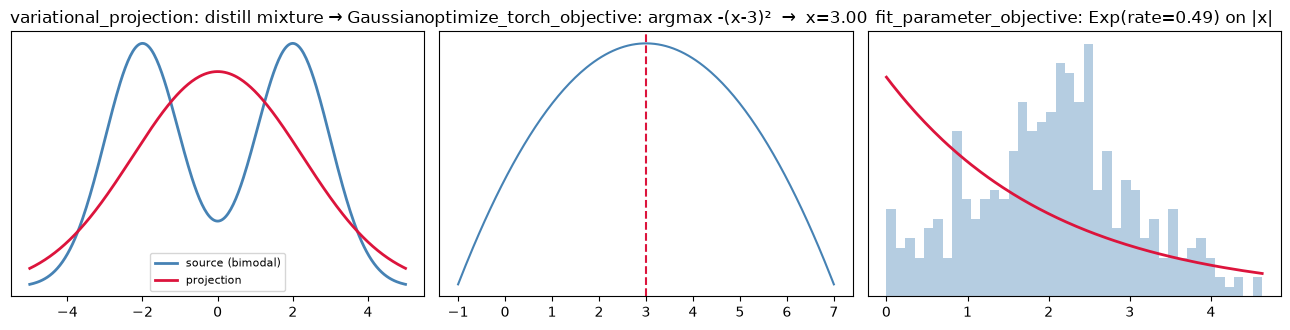

In [6]:
import torch

# (a) fit_objective: ExpectedLogDensity is just MLE — an anchor that it recovers the truth.
enc_raw = truth.dist_to_encoder().seq_encode(data)
ml_model, _ = fit_objective(enc_raw, truth, ExpectedLogDensity(), max_its=150, optimizer='lbfgs')
print('fit_objective (ExpectedLogDensity == MLE) recovers means',
      sorted(round(c.mu, 2) for c in ml_model.components))

# (b) variational_projection: distill a bimodal mixture into a single Gaussian (min KL).
src = MixtureDistribution([GaussianDistribution(-2, 1), GaussianDistribution(2, 1)], [0.5, 0.5])
proj, _ = variational_projection(src, GaussianDistribution(0.0, 1.0),
                                 sample_size=800, seed=1, optimizer='lbfgs')

# (c) optimize_torch_objective: raw tensor optimization, no model involved.
x = torch.tensor(0.0, requires_grad=True)
optimize_torch_objective([x], lambda: -(x - 3.0) ** 2, max_its=200)
xopt = float(x.detach())

# (d) fit_parameter_objective: a constrained named parameter — an exponential rate on |x|.
absd = np.abs(np.array(data)); xs = torch.tensor(absd)
rate_p = ObjectiveParameter('rate', 1.0, constraint='positive')
params, _ = fit_parameter_objective(
    {'rate': rate_p},
    lambda p, enc, eng: torch.sum(torch.log(p['rate']) - p['rate'] * xs), optimizer='lbfgs')
rate = float(params['rate'])

fig, ax = plt.subplots(1, 3, figsize=(13, 3.4))
g = np.linspace(-5, 5, 300)
ax[0].plot(g, np.exp([src.log_density(v) for v in g]),  color='steelblue', lw=2, label='source (bimodal)')
ax[0].plot(g, np.exp([proj.log_density(v) for v in g]), color='crimson',  lw=2, label='projection')
ax[0].set_title('variational_projection: distill mixture → Gaussian'); ax[0].legend(fontsize=8); ax[0].set_yticks([])
gg = np.linspace(-1, 7, 200)
ax[1].plot(gg, -(gg - 3) ** 2, color='steelblue'); ax[1].axvline(xopt, color='crimson', ls='--')
ax[1].set_title('optimize_torch_objective: argmax -(x-3)²  →  x=%.2f' % xopt); ax[1].set_yticks([])
ax[2].hist(absd, bins=40, density=True, alpha=0.4, color='steelblue')
ax[2].plot(np.sort(absd), rate * np.exp(-rate * np.sort(absd)), color='crimson', lw=2)
ax[2].set_title('fit_parameter_objective: Exp(rate=%.2f) on |x|' % rate); ax[2].set_yticks([])
fig.tight_layout(); plt.show()

## Choosing between models: log-likelihood, AIC, BIC

More parameters always fit the training data at least as well, so raw log-likelihood can't choose model size. AIC = 2k − 2·LL and BIC = k·ln(n) − 2·LL penalize the parameter count k (BIC harder, as n grows). Lower is better. Fit a 1-Gaussian and a 2-component mixture to the same data and let the criteria decide.


In [7]:
from mixle.stats import seq_log_density_sum, seq_encode
def info_criteria(model, k, data):
    ll = seq_log_density_sum(seq_encode(data, model=model), model)[1]
    n = len(data)
    return ll, 2*k - 2*ll, k*np.log(n) - 2*ll

for label, sample in [('bimodal data', list(np.r_[np.random.RandomState(0).normal(-3, 1, 400),
                                                  np.random.RandomState(1).normal(3, 1, 400)])),
                      ('unimodal data', list(np.random.RandomState(2).normal(0, 1, 800)))]:
    g  = optimize(sample, GaussianEstimator(), max_its=30, rng=np.random.RandomState(1), out=io.StringIO())
    _, mix = best_of(sample, sample, MixtureEstimator([GaussianEstimator(), GaussianEstimator()]),
                     trials=5, max_its=40, init_p=0.1, delta=1e-9, rng=np.random.RandomState(1), out=io.StringIO())
    print(label)
    for name, m, k in [('  1 Gaussian (k=2)', g, 2), ('  2-comp mix (k=5)', mix, 5)]:
        ll, aic, bic = info_criteria(m, k, sample)
        print('  %-20s LL=%8.0f  AIC=%8.0f  BIC=%8.0f' % (name, ll, aic, bic))
    print()

bimodal data
    1 Gaussian (k=2)   LL=   -2064  AIC=    4133  BIC=    4142
    2-comp mix (k=5)   LL=   -1674  AIC=    3359  BIC=    3382

unimodal data
    1 Gaussian (k=2)   LL=   -1147  AIC=    2298  BIC=    2308
    2-comp mix (k=5)   LL=   -1145  AIC=    2301  BIC=    2324



/Users/grantboquet/mixle/.ci-repro-colima/candidate-081/venv/lib/python3.12/site-packages/mixle/inference/estimation.py:2170: UserWarning: optimize() stopped at the max_its cap (40) before the objective settled (last objective gain 0.0178, delta=1e-09): the returned model is an unconverged fit, and its fit_provenance() reports converged=False. Raise max_its to fit to convergence, or pass delta=None to request a fixed iteration count without this note.
  mm = optimize(
/Users/grantboquet/mixle/.ci-repro-colima/candidate-081/venv/lib/python3.12/site-packages/mixle/inference/estimation.py:2170: UserWarning: optimize() stopped at the max_its cap (40) before the objective settled (last objective gain 0.0205, delta=1e-09): the returned model is an unconverged fit, and its fit_provenance() reports converged=False. Raise max_its to fit to convergence, or pass delta=None to request a fixed iteration count without this note.
  mm = optimize(
/Users/grantboquet/mixle/.ci-repro-colima/candidate-08